Dataset shape: (15, 14)

Cluster counts:
Cluster
0    2
1    3
2    1
3    9
Name: count, dtype: int64

Cluster 0: bield, leith, housing, port, 45am, care, 00pm, association, street, uk

Cluster 1: 30pm, hillcrest, cairn, 00am, 00pm, housing, 45pm, association, edinburgh, uk

Cluster 2: edinvar, castle, rock, castlerockedinvar, 657, 00am, 00pm, uk, support, sh_castlerockedinvar

Cluster 3: 00am, 00pm, uk, housing, edinburgh, http, www, association, search, org


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_11881/926971859.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


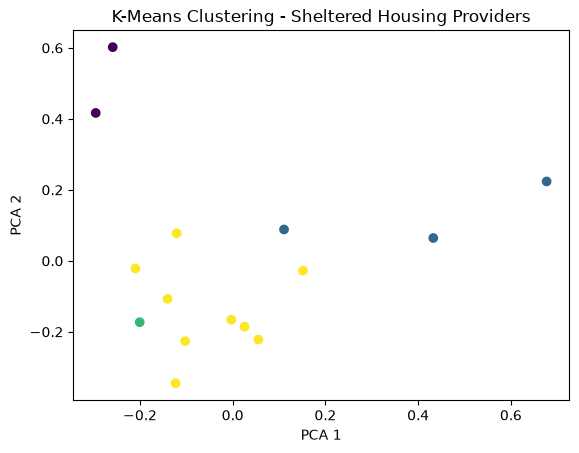


Done! Results saved.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("Sheltered Housing Providers.csv")

# Clean missing values
df = df.fillna("")

# Combine text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].agg(" ".join, axis=1)

# NLP - TF-IDF
tfidf = TfidfVectorizer(stop_words="english")
X = tfidf.fit_transform(df["text"])

# K-Means
k = 4
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# Results
print("Dataset shape:", df.shape)
print("\nCluster counts:")
print(df["Cluster"].value_counts().sort_index())

# Important words
words = tfidf.get_feature_names_out()
for i in range(k):
    top = model.cluster_centers_[i].argsort()[-10:][::-1]
    print(f"\nCluster {i}:", ", ".join(words[top]))

# PCA visualisation
pca = PCA(n_components=2)
points = pca.fit_transform(X.toarray())

plt.scatter(points[:,0], points[:,1], c=df["Cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering - Sheltered Housing Providers")
plt.show()

# Save results
df.to_csv("Sheltered_Housing_Providers_Clustered.csv", index=False)

print("\nDone! Results saved.")